K-Means Clustering on Red Wine Quality Dataset - 5/2/2026 - derave1577

In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
# Load the Red Wine dataset
data = pd.read_csv('winequality-red.csv')
# Display the first few rows to understand what the data looks like
display(Markdown("### Step 1: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())
# Get a concise summary of the DataFrame
print(data.info())
# Get descriptive statistics that summarize the central tendency,
# dispersion, and shape of the dataset's numerical features
display(data.describe())

### Step 1: Load the Dataset

Date: 2026-05-02

Student ID: derave1577

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [2]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
display(Markdown("### Step 2: Data Cleaning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Remove duplicates in the dataset
data = data.drop_duplicates().reset_index(drop=True)
# Check for missing values in the dataset
missing_values = data.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")
numerical_cols = data.select_dtypes(include=['number']).columns
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())
# Verify that there are no remaining missing values
missing_values_after = data.isnull().sum()
print(f"Missing values after cleaning:\n{missing_values_after}")
# Initialize the StandardScaler
scaler = StandardScaler()
# Select numerical features for scaling
numerical_features = data.select_dtypes(include=['number']).columns.tolist()
# Apply scaling
scaled_data = data.copy()
scaled_data[numerical_features] = scaler.fit_transform(data[numerical_features])
# Calculate z-scores for the scaled numerical features
for feature in numerical_features:
    scaled_data[f'{feature}_Z'] = zscore(scaled_data[feature])
# Remove outliers based on z-scores outside the range [-2, 2]
for feature in numerical_features:
    scaled_data = scaled_data[(scaled_data[f'{feature}_Z'] >= -2) & (scaled_data[f'{feature}_Z'] <= 2)]
# Drop the z-score columns as they are no longer needed
scaled_data = scaled_data.drop(columns=[f'{feature}_Z' for feature in numerical_features])
# Recalculate the scaling on the cleaned data
scaled_data[numerical_features] = scaler.fit_transform(scaled_data[numerical_features])
# Display the first few rows to verify the changes
display(scaled_data.head())

### Step 2: Data Cleaning

Date: 2026-05-02

Student ID: derave1577

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Missing values after cleaning:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.549323,1.139882,-1.396608,-0.604304,-0.268026,-0.433768,-0.289754,0.819196,1.537907,-0.604930,-0.993983,-0.846204
1,-0.253630,2.277081,-1.396608,0.528218,0.911287,1.243807,1.026717,0.123704,-0.977775,0.437627,-0.554726,-0.846204
2,-0.253630,1.518949,-1.169867,0.042852,0.589656,0.045539,0.508107,0.262803,-0.490869,0.176988,-0.554726,-0.846204
3,2.259758,-1.513583,1.777758,-0.604304,-0.321631,0.285193,0.747466,0.958294,-1.302379,-0.431171,-0.554726,0.535294
4,-0.549323,0.887171,-1.396608,-0.766093,-0.321631,-0.194114,-0.050396,0.819196,1.537907,-0.604930,-0.993983,-0.846204


### Step 3: Hierarchical Clustering

Date: 2026-05-02

Student ID: derave1577

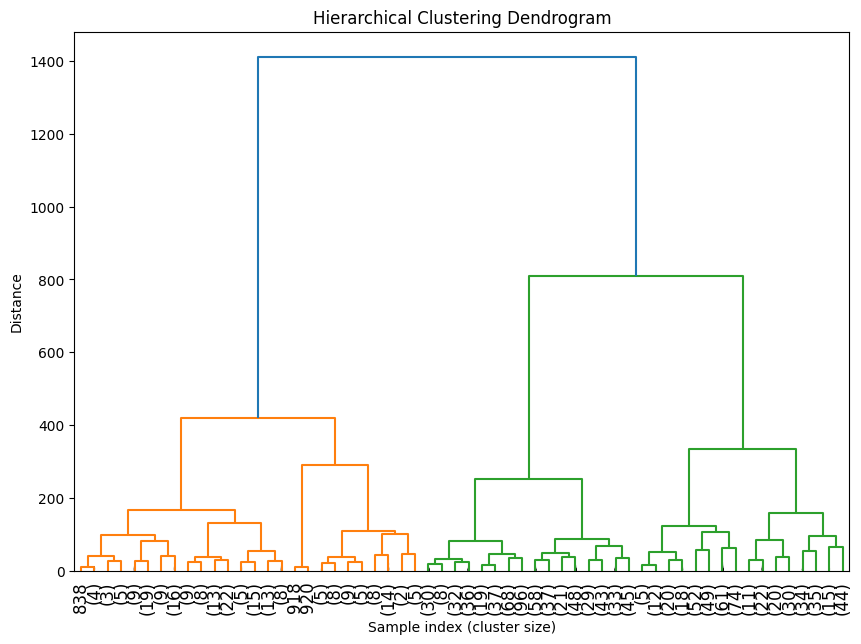

In [4]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
display(Markdown("### Step 3: Hierarchical Clustering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Perform hierarchical clustering to find a starting k
Z = linkage(data, method='ward')
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index (cluster size)')
plt.ylabel('Distance')
plt.show()

### Step 4: K-Means Clustering

Date: 2026-05-02

Student ID: derave1577

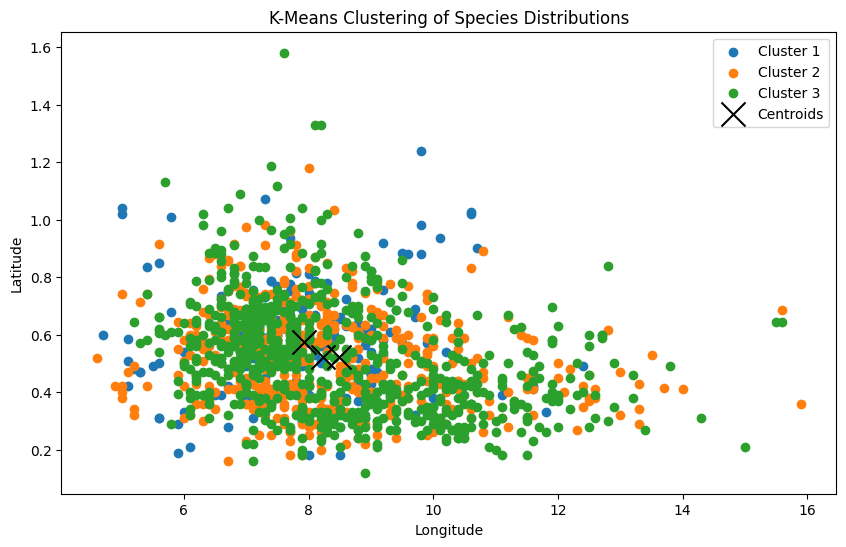

In [7]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
display(Markdown("### Step 4: K-Means Clustering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize the KMeans model
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
# Fit the model to the data
kmeans.fit(data)
# Get the cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
# Plot the clusters
plt.figure(figsize=(10, 6))
for i in range(k):
    cluster_points = data[labels == i]
    plt.scatter(cluster_points.iloc[:, 0], cluster_points.iloc[:, 1], label=f'Cluster {i + 1}')
# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='x', label='Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering of Species Distributions')
plt.legend()
plt.show()

### Step 5: Optimizing K-Means Clustering with Elbow Method

Date: 2026-05-02

Student ID: derave1577

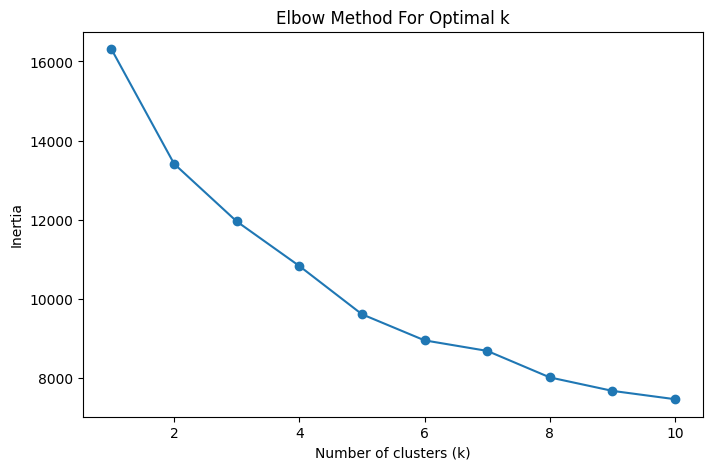

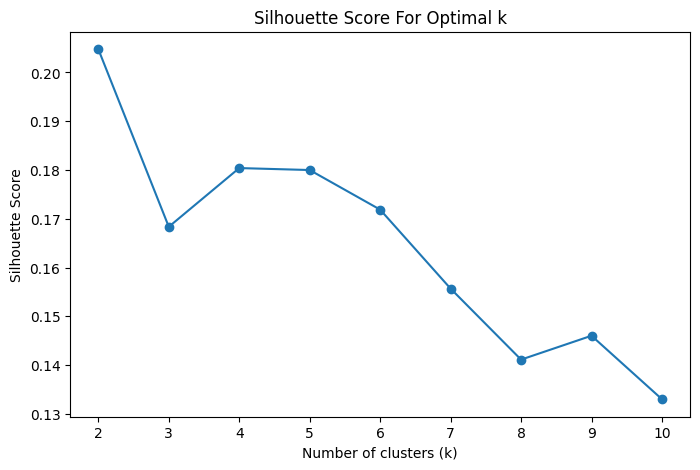

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
display(Markdown("### Step 5: Optimizing K-Means Clustering with Elbow Method"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
# Use Elbow Method to find optimal k
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()
# Silhouette Score
silhouette_scores = []
# Calculate the Silhouette Score to find optimal k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    # Silhouette score is only defined for k > 1
    if k > 1:
        score = silhouette_score(scaled_data, kmeans.labels_)
        silhouette_scores.append(score)
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values[1:], silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Optimal k')
plt.show()

In [15]:
display(Markdown("### Step 6: Refitting the Model using Optimal Number of Clusters"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Set the optimal number of clusters found from your plots
optimal_k = 2
# Refit the K-Means model
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(data)
# Calculate and display the Silhouette Score
score = silhouette_score(data, cluster_labels)
print(f"Optimal Number of Clusters: {optimal_k}")
print(f"Silhouette Score for k={optimal_k}: {score}")

### Step 6: Refitting the Model using Optimal Number of Clusters

Date: 2026-05-02

Student ID: derave1577

Optimal Number of Clusters: 2
Silhouette Score for k=2: 0.6018934167302308
